# Longitudinal Modulus from Compression: Final Equilibrated State

## Theory

$$M = \frac{\sigma'_{zz}}{\varepsilon_{zz}}$$

Network stress from poroelasticity decomposition:
$$p_p(z) = -\frac{\sigma_{s,zz}(z)}{\phi_s(z)}, \qquad \sigma'_{zz}(z) = \sigma_{p,zz}(z) + \phi_p(z)\,p_p(z)$$

Cooperative diffusivity from relaxation:
$$\frac{\partial \phi_p}{\partial t} = D_c \frac{\partial^2 \phi_p}{\partial z^2}$$

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from scipy import stats
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
import os
from pathlib import Path
import matplotlib.font_manager as fm

plt.rcParams.update({
    'font.family': 'CMU Serif',
    'mathtext.fontset': 'cm',
    'mathtext.rm': 'CMU Serif',
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 25,
    'xtick.labelsize': 23,
    'ytick.labelsize': 23,
    'legend.fontsize': 23,
    'figure.titlesize': 22,
})

print('Imports successful')


Imports successful


## Configuration

In [7]:
sim_name = 'walled_slab_support_5beads_tall_rho04_p1.5_1.0_1.0_600000_1.0_1.0_2000000'
stress_data_dir = '../../flow_data_local/partial_stress_data/walled_slab_support_5beads_tall_rho04_p1.5_1.0_1.0_600000_1.0_1.0_2000000/'
traj_file = f'../../flow_data_local/traj_files.nosync/gel_flow_{sim_name}.lammpstrj'
output_folder = '../../flow_data_local/flow_plots/walled_slab_support_5beads_tall_rho04_p1.5_1.0_1.0_600000_1.0_1.0_2000000/'
binWidth = 2.0
phi_gel_threshold = 0.1
ci_level = 0.95

## Helper Functions

In [10]:
def read_ave_time_file(filepath):
    data_by_time = []
    with open(filepath, 'r') as f:
        lines = [l for l in f if not l.startswith('#') and l.strip()]
    i = 0
    while i < len(lines):
        parts = lines[i].split()
        if len(parts) == 2:
            timestep, nrows = int(parts[0]), int(parts[1])
            values = []
            for j in range(1, nrows + 1):
                if i + j < len(lines):
                    vp = lines[i + j].split()
                    if len(vp) == 2:
                        values.append(float(vp[1]))
            if values:
                data_by_time.append((timestep, np.arange(1, len(values)+1), np.array(values)))
            i += nrows + 1
        else:
            i += 1
    return data_by_time


def read_strain_file(filepath):
    rows = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'): continue
            rows.append([float(v) for v in line.split()])
    if not rows:
        raise ValueError(f'No data in {filepath}')
    if len(rows) == 2 and all(len(r)==1 for r in rows):
        return None, np.array([rows[0][0]]), np.array([rows[1][0]])
    if len(rows) == 1 and len(rows[0]) == 2:
        return None, np.array([rows[0][0]]), np.array([rows[0][1]])
    if all(len(r)==3 for r in rows):
        arr = np.array(rows)
        ts, col1, col2 = arr[:,0].astype(int).tolist(), arr[:,1], arr[:,2]
        ratio = np.nanmedian(col2) / np.nanmedian(col1)
        dL = col2 if ratio < 0.5 else col1 - col2
        return ts, col1, dL
    raise ValueError(f'Unrecognised format in {filepath}')


def read_lammpstrj_frame(filepath, frame_idx=0):
    with open(filepath) as f:
        lines = f.readlines()
    starts = [i for i,l in enumerate(lines) if 'ITEM: TIMESTEP' in l]
    if frame_idx < 0: frame_idx = len(starts) + frame_idx
    s = starts[frame_idx]
    e = starts[frame_idx+1] if frame_idx+1<len(starts) else len(lines)
    fl = lines[s:e]
    timestep = int(fl[1].strip())
    box = {'x': [float(v) for v in fl[5].split()],
           'y': [float(v) for v in fl[6].split()],
           'z': [float(v) for v in fl[7].split()]}
    atoms = [[int(p[0]),int(p[1]),int(p[2]),float(p[3]),float(p[4]),float(p[5])]
             for p in [l.split() for l in fl[9:9+int(fl[3].strip())]]]
    return timestep, box, atoms


def compute_volume_fractions_1d(atoms_data, box_bounds, bin_width, direction='z'):
    a = np.array(atoms_data)
    typ, pos = a[:,1].astype(int), a[:,3:6]
    pm, sm = (typ==1)|(typ==2), (typ==3)
    d = {'x':0,'y':1,'z':2}[direction]
    lo, hi = box_bounds[direction]
    edges = np.arange(lo, hi+bin_width, bin_width)
    centers = (edges[:-1]+edges[1:])/2
    phi_p, phi_s = np.zeros(len(centers)), np.zeros(len(centers))
    for i,(a_,b_) in enumerate(zip(edges[:-1],edges[1:])):
        mask = (pos[:,d]>=a_)&(pos[:,d]<b_)
        np_, ns_, nt = np.sum(pm&mask), np.sum(sm&mask), np.sum(mask)
        if nt>0: phi_p[i], phi_s[i] = np_/nt, ns_/nt
    return centers, phi_p, phi_s

def compute_volume_fractions_1d_voronoi(atoms_data, box_bounds, bin_width, direction='z'):
    import tess
    import time

    a = np.array(atoms_data)
    typ = a[:,1].astype(int)
    pos = a[:,3:6]

    xlo, xhi = box_bounds['x']
    ylo, yhi = box_bounds['y']
    zlo, zhi = box_bounds['z']
    L = np.array([xhi-xlo, yhi-ylo, zhi-zlo])
    origin = np.array([xlo, ylo, zlo])

    # Filter to mobile atoms only (polymer + solvent) — exclude walls/support/piston
    mobile_mask = (typ == 1) | (typ == 2) | (typ == 3)
    typ_m = typ[mobile_mask]
    pos_m = pos[mobile_mask]

    # Wrap into box
    pos_wrapped = origin + (pos_m - origin) % L

    # Check for duplicates — voro++ will fail on coincident points
    print(f'  Checking for duplicate positions...')
    _, unique_idx = np.unique(np.round(pos_wrapped, 6), axis=0, return_index=True)
    n_dupes = len(pos_wrapped) - len(unique_idx)
    if n_dupes > 0:
        print(f'  Warning: removing {n_dupes} duplicate positions')
        pos_wrapped = pos_wrapped[unique_idx]
        typ_m = typ_m[unique_idx]

    print(f'  Building Voronoi container ({len(pos_wrapped)} atoms)...')
    t0 = time.time()
    cntr = tess.Container(
        pos_wrapped,
        limits=((xlo, ylo, zlo), (xhi, yhi, zhi)),
        periodic=True
    )
    print(f'  Container built ({time.time()-t0:.1f}s)')

    print(f'  Extracting cell volumes...')
    t0 = time.time()
    voronoi_volumes = np.array([c.volume() for c in cntr])
    print(f'  Volumes extracted ({time.time()-t0:.1f}s)')

    # Sanity check
    box_vol = L[0] * L[1] * L[2]
    voro_total = np.sum(voronoi_volumes)
    if abs(voro_total - box_vol) / box_vol > 0.01:
        print(f'  Warning: Voronoi volume {voro_total:.2f} differs from box {box_vol:.2f} by '
              f'{100*abs(voro_total-box_vol)/box_vol:.1f}%')

    # Bin along direction
    d = {'x': 0, 'y': 1, 'z': 2}[direction]
    lo, hi = box_bounds[direction]
    edges   = np.arange(lo, hi + bin_width, bin_width)
    centers = (edges[:-1] + edges[1:]) / 2

    pm = (typ_m == 1) | (typ_m == 2)
    sm = (typ_m == 3)

    phi_p = np.zeros(len(centers))
    phi_s = np.zeros(len(centers))

    for i, (a_, b_) in enumerate(zip(edges[:-1], edges[1:])):
        mask    = (pos_wrapped[:, d] >= a_) & (pos_wrapped[:, d] < b_)
        V_p     = np.sum(voronoi_volumes[mask & pm])
        V_s     = np.sum(voronoi_volumes[mask & sm])
        V_total = np.sum(voronoi_volumes[mask])
        if V_total > 0:
            phi_p[i] = V_p / V_total
            phi_s[i] = V_s / V_total

    return centers, phi_p, phi_s


def mean_ci(values, ci_level=0.95):
    v = values[~np.isnan(values)]
    n = len(v)
    if n==0: return np.nan, np.nan, np.nan
    if n==1: return v[0], v[0], v[0]
    m = np.mean(v)
    lo, hi = stats.t.interval(ci_level, df=n-1, loc=m, scale=stats.sem(v))
    return m, lo, hi


print('Helper functions defined')

Helper functions defined


## Step 1: Extract All Data

Reads data files

In [ ]:
# ── Read stress data ──
stress_data = {}
for key, fp in [
    ('polymer_z', f'{stress_data_dir}stress_z_polymer_{sim_name}.dat'),
    ('solvent_z', f'{stress_data_dir}stress_z_solvent_{sim_name}.dat'),
]:
    print(f'Reading {key} ...')
    stress_data[key] = read_ave_time_file(fp)

n_stress = len(stress_data['polymer_z'])
print(f'Stress snapshots: {n_stress}')

# ── Read strain ──
strain_file = f'{stress_data_dir}strain_zz_{sim_name}.dat'
ts_strain, L_arr, dL_arr = read_strain_file(strain_file)
L_final  = L_arr[-1]  if len(L_arr)>1 else L_arr[0]
dL_final = dL_arr[-1] if len(dL_arr)>1 else dL_arr[0]
eps_final = dL_final / L_final
print(f'Final: L={L_final:.4f}, ΔL={dL_final:.4f}, ε={eps_final:.4f}')

# ── Match stress snapshots to trajectory frames ──
traj_timestep_to_frame = {}
with open(traj_file) as f:
    lines = f.readlines()
starts = [i for i,l in enumerate(lines) if 'ITEM: TIMESTEP' in l]
for frame_idx, s in enumerate(starts):
    traj_timestep_to_frame[int(lines[s+1].strip())] = frame_idx

print(f'Trajectory frames: {len(starts)}')

matched = []
for idx in range(n_stress):
    stress_ts = stress_data['polymer_z'][idx][0]
    if stress_ts in traj_timestep_to_frame:
        matched.append((idx, traj_timestep_to_frame[stress_ts]))
    else:
        nearest = min(traj_timestep_to_frame.keys(), key=lambda t: abs(t - stress_ts))
        print(f'  Warning: stress ts={stress_ts} not in traj, using nearest ts={nearest}')
        matched.append((idx, traj_timestep_to_frame[nearest]))

n_snapshots = len(matched)
print(f'Matched {n_snapshots} snapshots')

# ── Loop once: extract everything ──
all_timesteps      = []
all_phi_p          = []  # count-based
all_phi_s          = []  # count-based
all_sigma_p_zz     = []
all_sigma_s_zz     = []
z_cnt = None  # count-based z grid (normalised), set on first iteration

for count, (stress_idx, frame_idx) in enumerate(matched):
    if (count+1) % max(1, n_snapshots//9) == 0 or count == 0:
        print(f'  {count+1}/{n_snapshots}')

    _, box, atoms = read_lammpstrj_frame(traj_file, frame_idx)

    # Count-based volume fractions
    z_i, phi_p_i, phi_s_i = compute_volume_fractions_1d(atoms, box, binWidth, 'z')
    all_phi_p.append(phi_p_i)
    all_phi_s.append(phi_s_i)

    if z_cnt is None:
        zlo, zhi = box['z']
        Lz = zhi - zlo
        z_cnt = (z_i - zlo) / Lz

    # Stress profiles
    ts = stress_data['polymer_z'][stress_idx][0]
    bins_z = stress_data['polymer_z'][stress_idx][1]
    z_coords = bins_z * binWidth - binWidth/2
    sig_p = stress_data['polymer_z'][stress_idx][2]
    sig_s = stress_data['solvent_z'][stress_idx][2]

    all_timesteps.append(ts)
    all_sigma_p_zz.append(sig_p)
    all_sigma_s_zz.append(sig_s)

z_norm = (z_coords - zlo) / Lz
all_phi_p = np.array(all_phi_p)
all_phi_s = np.array(all_phi_s)

print(f'\nDone. t = {all_timesteps[0]} → {all_timesteps[-1]}')
print(f'φ_p shape: {all_phi_p.shape}')

# Aliases for backward compatibility with later cells
z_centers = z_i
z_centers_norm = z_cnt


Reading polymer_z ...
Reading solvent_z ...
Stress snapshots: 9
Final: L=113.8394, ΔL=11.4948, ε=0.1010
Trajectory frames: 200
Matched 9 snapshots
  1/9
  2/9
  3/9
  4/9
  5/9
  6/9
  7/9
  8/9
  9/9

Done. t = 400000 → 2000000
φ_p shape: (9, 71)


## Step 2: Partial Stress Evolution

Saved: ../../flow_data_local/flow_plots/walled_slab_support_5beads_tall_rho04_p1.5_1.0_1.0_600000_1.0_1.0_2000000/equilibration_check_walled_slab_support_5beads_tall_rho04_p1.5_1.0_1.0_600000_1.0_1.0_2000000.png


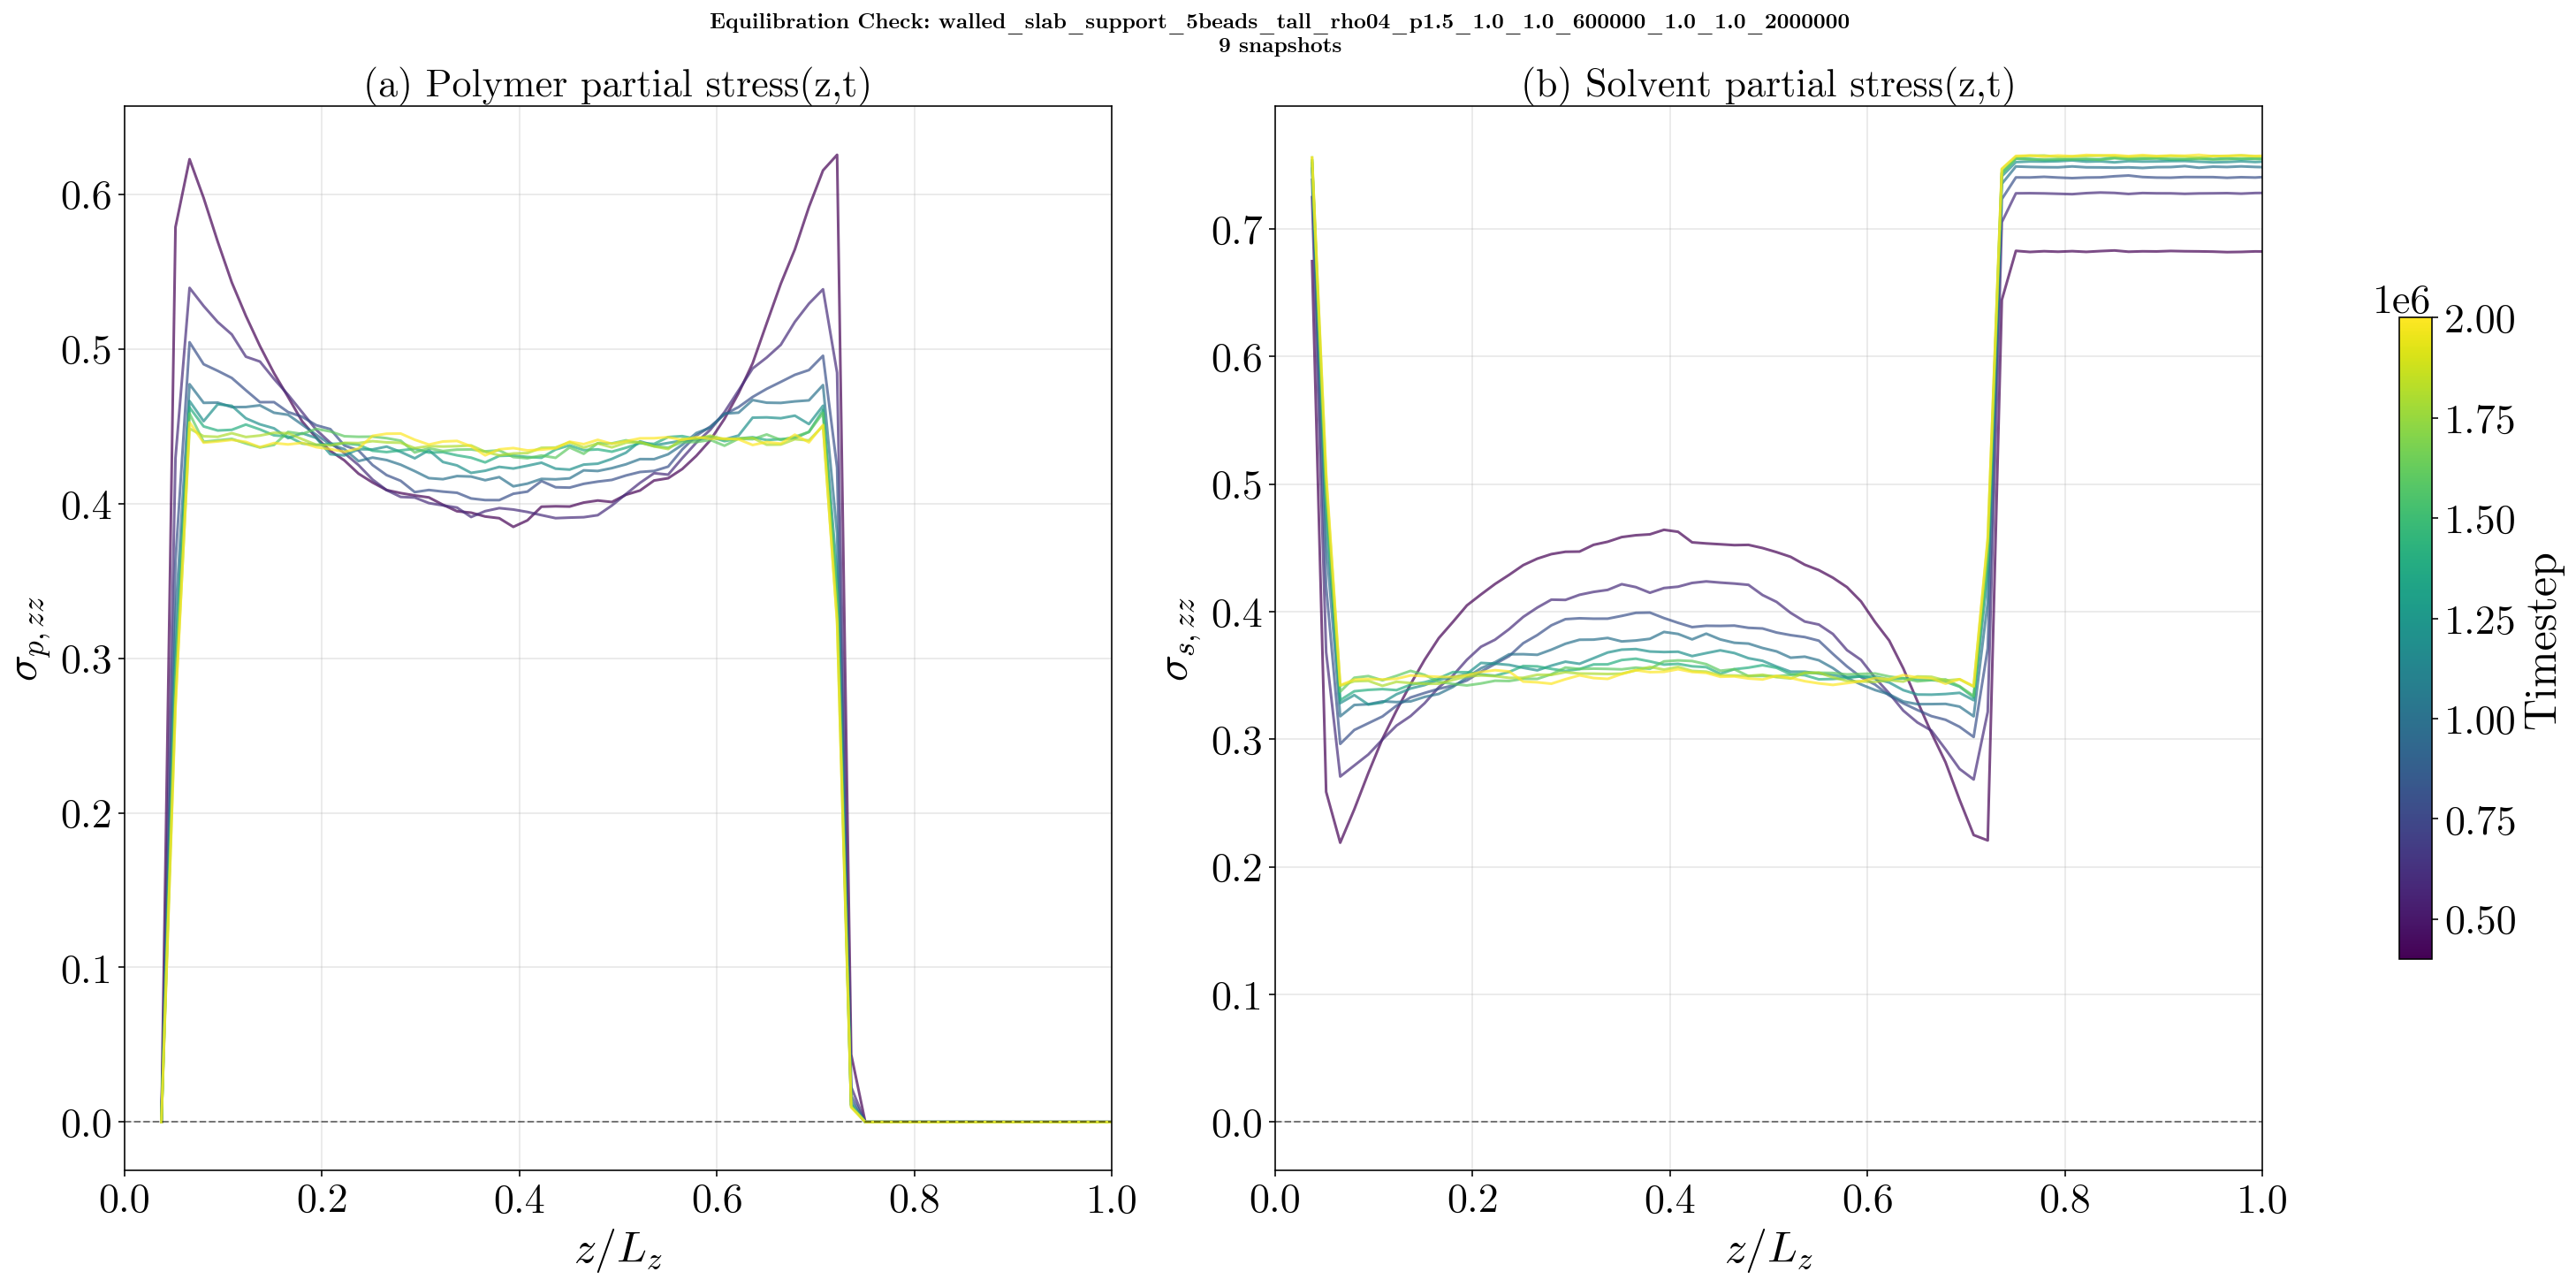

In [13]:
colors = plt.cm.viridis(np.linspace(0, 1, n_snapshots))
alpha = 0.7

fig = plt.figure(figsize=(20, 10), constrained_layout=True)
fig.suptitle(
    f'Equilibration Check: {sim_name}\n{n_snapshots} snapshots',
    fontsize=12, fontweight='bold')

gs = gridspec.GridSpec(1, 2, figure=fig)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])

for i in range(n_snapshots):
    ax_a.plot(z_norm, all_sigma_p_zz[i], '-', color=colors[i], lw=1.5, alpha=alpha)
ax_a.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax_a.set(xlabel='$z/L_z$', ylabel=r'$\sigma_{p,zz}$', title=r'(a) Polymer partial stress(z,t)', xlim=(0,1))
ax_a.grid(alpha=0.3)

for i in range(n_snapshots):
    ax_b.plot(z_norm, all_sigma_s_zz[i], '-', color=colors[i], lw=1.5, alpha=alpha)
ax_b.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax_b.set(xlabel='$z/L_z$', ylabel=r'$\sigma_{s,zz}$', title=r'(b) Solvent partial stress(z,t)', xlim=(0,1))
ax_b.grid(alpha=0.3)

sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=Normalize(vmin=all_timesteps[0], vmax=all_timesteps[-1]))
sm.set_array([])
cb = fig.colorbar(sm, ax=[ax_a, ax_b], fraction=0.015, pad=0.04)
cb.set_label('Timestep')

out1 = Path(output_folder) / f'equilibration_check_{sim_name}.png'
plt.savefig(out1, dpi=150, bbox_inches='tight')
print(f'Saved: {out1}')
plt.show()


## Step 3: Polymer Volume Fraction Evolution

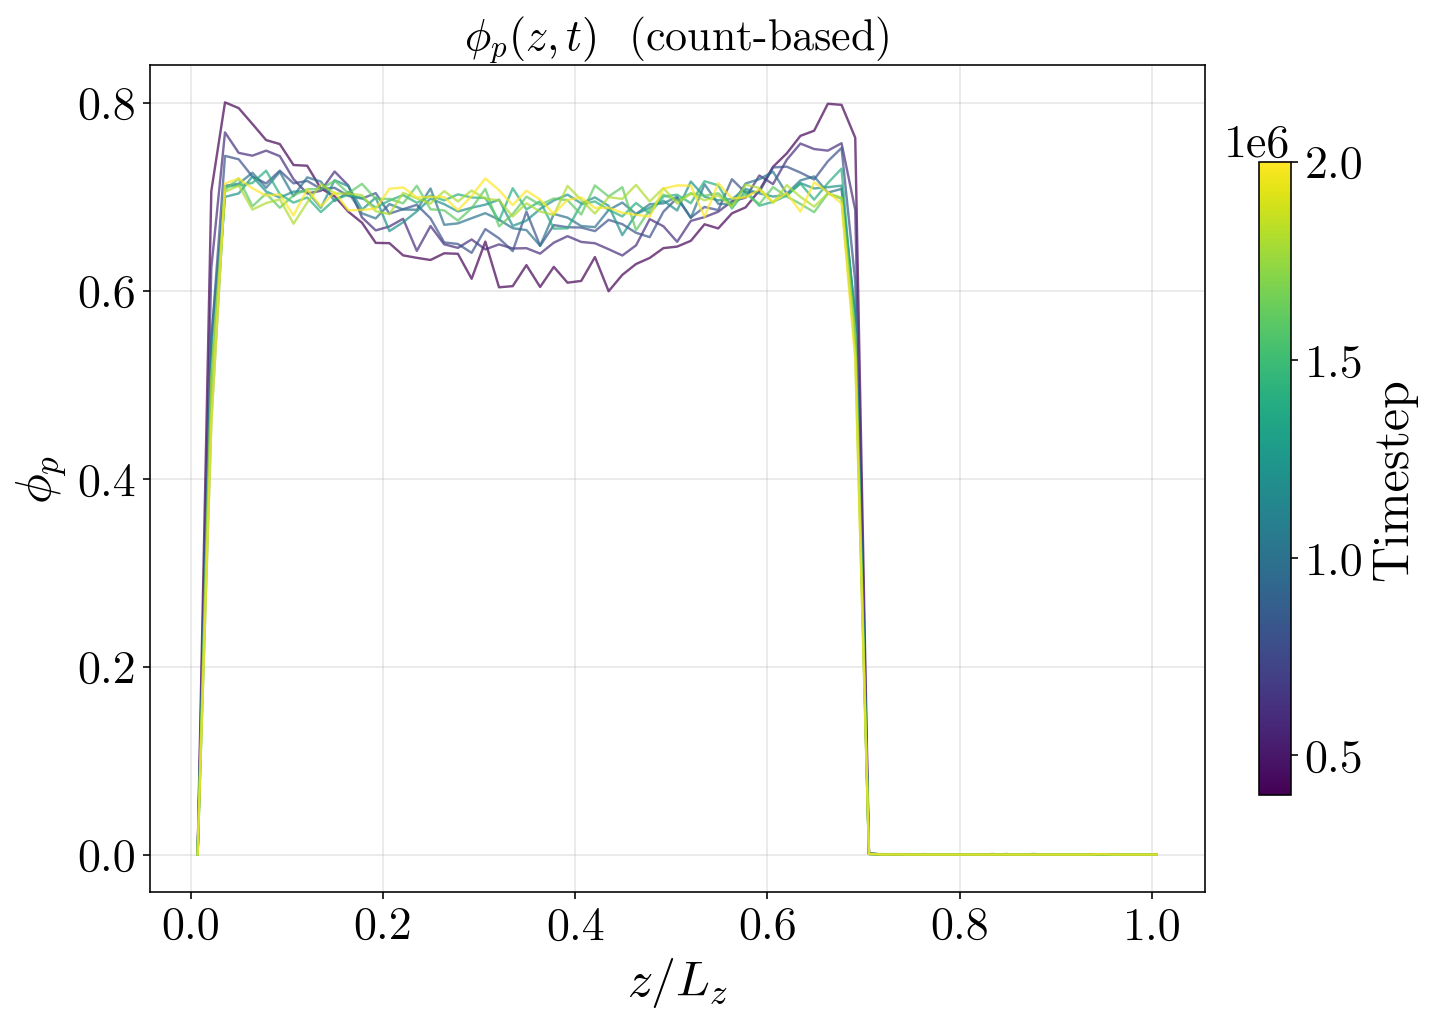

In [14]:
fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
norm = Normalize(vmin=all_timesteps[0], vmax=all_timesteps[-1])
cmap = plt.cm.viridis

for i in range(n_snapshots):
    ax.plot(z_cnt, all_phi_p[i], '-', color=cmap(norm(all_timesteps[i])), lw=1.2, alpha=0.7)

ax.set(xlabel='$z / L_z$', ylabel=r'$\phi_p$', title=r'$\phi_p(z, t)$  (count-based)')
ax.grid(alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('Timestep')

plt.savefig(Path(output_folder) / f'phi_p_evolution_{sim_name}.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 4: Cooperative Diffusivity $D_c$ — Fourier cosine fit

Fit $D_c$ to the even-mode cosine series (wall symmetry kills odd modes):

$$\phi_p(z, t) = \phi_p^0 + (\phi_p^1 - \phi_p^0)\left[1 + 2\sum_{k=1}^{N} \cos\!\left(\frac{2\pi k\, z}{L_\text{gel}}\right) e^{-4\pi^2 k^2 \tau_\text{eff}}\right], \qquad \tau_\text{eff} = \frac{D_c\, t}{L_\text{gel}^2} + \frac{1}{16\pi}$$

where $\tau_0 = 1/16\pi$ is the regularisation offset enforcing $\phi_p(0,\,0) = 2\phi_p^1 - \phi_p^0$. $D_c$ is fit over the full gel domain across the first `frac_early` fraction of snapshots.

In [111]:
from scipy.optimize import minimize_scalar
from matplotlib.colors import Normalize

# ── USER INPUTS ────────────────────────────────────────────────────────────────
edge_margin  = 0
binWidth_Dc  = binWidth
dt_lj        = 0.005

frac_early   = 0.4 # use 0.25 for the Gaussian solution
N_modes      = 2                # number of Fourier modes (k=1..N); more → better fit
Dc_bounds    = (1e-6, 1.0)
# ── END USER INPUTS ────────────────────────────────────────────────────────────


# ── Gel domain ────────────────────────────────────────────────────────────────
gel_bins = np.where(all_phi_p[0] > phi_gel_threshold)[0]
i_left   = gel_bins[0]  + edge_margin
i_right  = gel_bins[-1] - edge_margin + 1

z_gel    = z_cnt[i_left:i_right]
z_L      = z_gel[0]

times     = np.array(all_timesteps, dtype=float)
dt_lj_arr = (times - times[0]) * dt_lj      # elapsed time in LJ τ

#phi_gel  = all_phi_p[:, i_left:i_right]

In [90]:
# ── VORONOI φ_p  (comment out to use count-based) ────────────────────────────
phi_gel_vor = np.zeros_like(phi_gel)
for fi, (_, byte_offset) in enumerate(matched):
    _, box_v, atoms_v = read_lammpstrj_frame(traj_file, byte_offset)
    box_bounds_v = {'x': box_v['x'], 'y': box_v['y'], 'z': box_v['z']}
    z_v, phi_p_v, _ = compute_volume_fractions_1d_voronoi(atoms_v, box_bounds_v, 4, 'z')
    phi_gel[fi] = interp1d(z_v, phi_p_v, bounds_error=False, fill_value=0.0)(z_gel)
    print(f'  Voronoi: frame {fi+1}/{len(matched)} done', end='\r')
print('  Voronoi: all frames done        ')
# ── END VORONOI ───────────────────────────────────────────────────────────────

  Checking for duplicate positions...
  Building Voronoi container (187096 atoms)...
  Container built (17.6s)
  Extracting cell volumes...
  Volumes extracted (1.9s)
  Checking for duplicate positions...
  Building Voronoi container (187096 atoms)...
  Container built (18.5s)
  Extracting cell volumes...
  Volumes extracted (1.9s)
  Checking for duplicate positions...
  Building Voronoi container (187096 atoms)...
  Container built (17.9s)
  Extracting cell volumes...
  Volumes extracted (2.1s)
  Checking for duplicate positions...
  Building Voronoi container (187096 atoms)...
  Container built (18.8s)
  Extracting cell volumes...
  Volumes extracted (1.7s)
  Checking for duplicate positions...
  Building Voronoi container (187096 atoms)...
  Container built (21.6s)
  Extracting cell volumes...
  Volumes extracted (2.0s)
  Checking for duplicate positions...
  Building Voronoi container (187096 atoms)...
  Container built (25.1s)
  Extracting cell volumes...
  Volumes extracted (2.3s

In [140]:
# ── Geometry ──────────────────────────────────────────────────────────────────
L_gel_sigma = len(z_gel) * binWidth_Dc
zeta_sigma  = z_gel - z_L
zhat        = zeta_sigma / L_gel_sigma

half_mask = (zeta_sigma > 0) & (zeta_sigma <= L_gel_sigma / 2.0)
zhat_fit = zhat   # full [0, 1] domain
early_idx = np.arange(1, len(times))         # all snapshots after t0

fit_mask = np.ones(len(zhat), dtype=bool)
fit_mask[:trim_bins] = False
fit_mask[-trim_bins:] = False
zhat_fit = zhat[fit_mask]


print(f'L_gel = {L_gel_sigma:.1f} σ,  {len(zhat_fit)} bins in fit domain,  '
      f'{len(early_idx)} snapshots')

# ── Early-time snapshot selection ─────────────────────────────────────────────
max_dt_steps = (times[-1] - t0) * frac_early
early_mask   = dt_arr <= max_dt_steps
early_idx    = np.where(early_mask)[0]

if len(early_idx) == 0:
    raise RuntimeError(
        f'No early snapshots found with frac_early={frac_early}. '
        f'Total steps = {times[-1]-t0:.0f}. Try increasing frac_early.')

print(f'Early snapshots: {len(early_idx)} / {len(times)-1}  '
      f'(first {frac_early*100:.0f}% = {max_dt_steps:.0f} steps = {max_dt_steps*dt_lj:.1f} τ)')

# ── Reference volume fractions ────────────────────────────────────────────────
trim_bins = 2                                        # user-tunable
interior = phi_gel[0, trim_bins:-trim_bins]
phi_pi   = float(np.max(interior))
print(f'Auto φ_p^i = {phi_pi:.4f}  (max of gel bins')

phi_p1 = float(np.mean(phi_gel[-1, :]))
print(f'Auto φ_p^1 = {phi_p1:.4f}  (gel-averaged final frame)')

phi_p0 = float(np.min(interior))
print(f'Auto φ_p^0 = {phi_p0:.4f}  float(np.min(interior))')

#print(interior)
#print(early_idx)
#plt.plot(zhat, phi_gel[0], 'o-', color=c, ms=3, alpha=0.6)

# ── Model: Fourier cosine series (even modes, wall symmetry) ──────────────────
# phi = phi0 + (phi1-phi0) * [1 + 2*Σ_{k=1}^{N} cos(2πk·zh)·exp(-4π²k²·τ_eff)]
# τ_eff = Dc·t/L² + 1/(16π)   [regularisation offset same as Gaussian t0]
def fourier_model(zh, Dc, t_lj_val):
    """zh: z/L_gel in [0, 1]."""
    tau_eff = Dc * t_lj_val / L_gel_sigma**2 + 1.0 / (16.0 * np.pi)
    s = np.ones_like(zh, dtype=float)
    for k in range(1, N_modes + 1):
        s += 2.0 * np.cos(2.0 * np.pi * k * zh) * np.exp(-4.0 * np.pi**2 * k**2 * tau_eff)
    return phi_p0 + (phi_p1 - phi_p0) * s

# # ── Gaussian model (commented out) ───────────────────────────────────────────
# def gaussian_model(zeta_s, Dc, t_lj_val):
#     t0_reg  = L_gel_sigma**2 / (16.0 * np.pi * Dc)
#     t_prime = t_lj_val + t0_reg
#     prefac  = (phi_p1 - phi_p0) * L_gel_sigma / np.sqrt(4.0 * np.pi * Dc * t_prime)
#     return phi_p0 + prefac * np.exp(-zeta_s**2 / (4.0 * Dc * t_prime))

# ── Fit ───────────────────────────────────────────────────────────────────────
def residual(Dc):
    return sum(
        np.sum((fourier_model(zhat_fit, Dc, dt_lj_arr[i]) - phi_gel[i][fit_mask])**2)
        for i in early_idx
    )
res        = minimize_scalar(residual, bounds=Dc_bounds, method='bounded')
Dc_fit     = res.x
tau0       = 1.0 / (16.0 * np.pi)
t0_reg     = tau0 * L_gel_sigma**2 / Dc_fit

# ── Validity check ────────────────────────────────────────────────────────────
tau_eff_last  = Dc_fit * dt_lj_arr[early_idx[-1]] / L_gel_sigma**2 + tau0
diffusion_len = np.sqrt(Dc_fit * (dt_lj_arr[early_idx[-1]] + t0_reg))
validity_ok   = diffusion_len < L_gel_sigma / 2.0

# ── R² per snapshot + aggregate ───────────────────────────────────────────────
R2_per = []
for i in early_idx:
    y    = phi_gel[i][fit_mask]
    yhat = fourier_model(zhat_fit, Dc_fit, dt_lj_arr[i])
    ss_r  = np.sum((y - yhat)**2)
    ss_t  = np.sum((y - np.mean(y))**2)
    R2_per.append(1.0 - ss_r / ss_t)

phi_data_all = np.concatenate([phi_gel[i][fit_mask] for i in early_idx])
phi_pred_all = np.concatenate([fourier_model(zhat_fit, Dc_fit, dt_lj_arr[i])
                                for i in early_idx])
ss_res = np.sum((phi_data_all - phi_pred_all)**2)
ss_tot = np.sum((phi_data_all - np.mean(phi_data_all))**2)
R2     = 1.0 - ss_res / ss_tot

L_gel = 96.0 σ,  44 bins in fit domain,  8 snapshots
Early snapshots: 4 / 8  (first 40% = 640000 steps = 3200.0 τ)
Auto φ_p^i = 0.6279  (max of gel bins
Auto φ_p^1 = 0.4568  (gel-averaged final frame)
Auto φ_p^0 = 0.3708  float(np.min(interior))


Saved: ../../flow_data_local/flow_plots/walled_slab_support_5beads_tall_rho04_p1.5_1.0_1.0_600000_1.0_1.0_2000000/Dc_fourier_fit_walled_slab_support_5beads_tall_rho04_p1.5_1.0_1.0_600000_1.0_1.0_2000000.png
  R² (aggregate) = 0.797403
  R² per snapshot:
    step 400000  →  R² = 0.848
    step 600000  →  R² = 0.804
    step 800000  →  R² = 0.763
    step 1000000  →  R² = 0.356


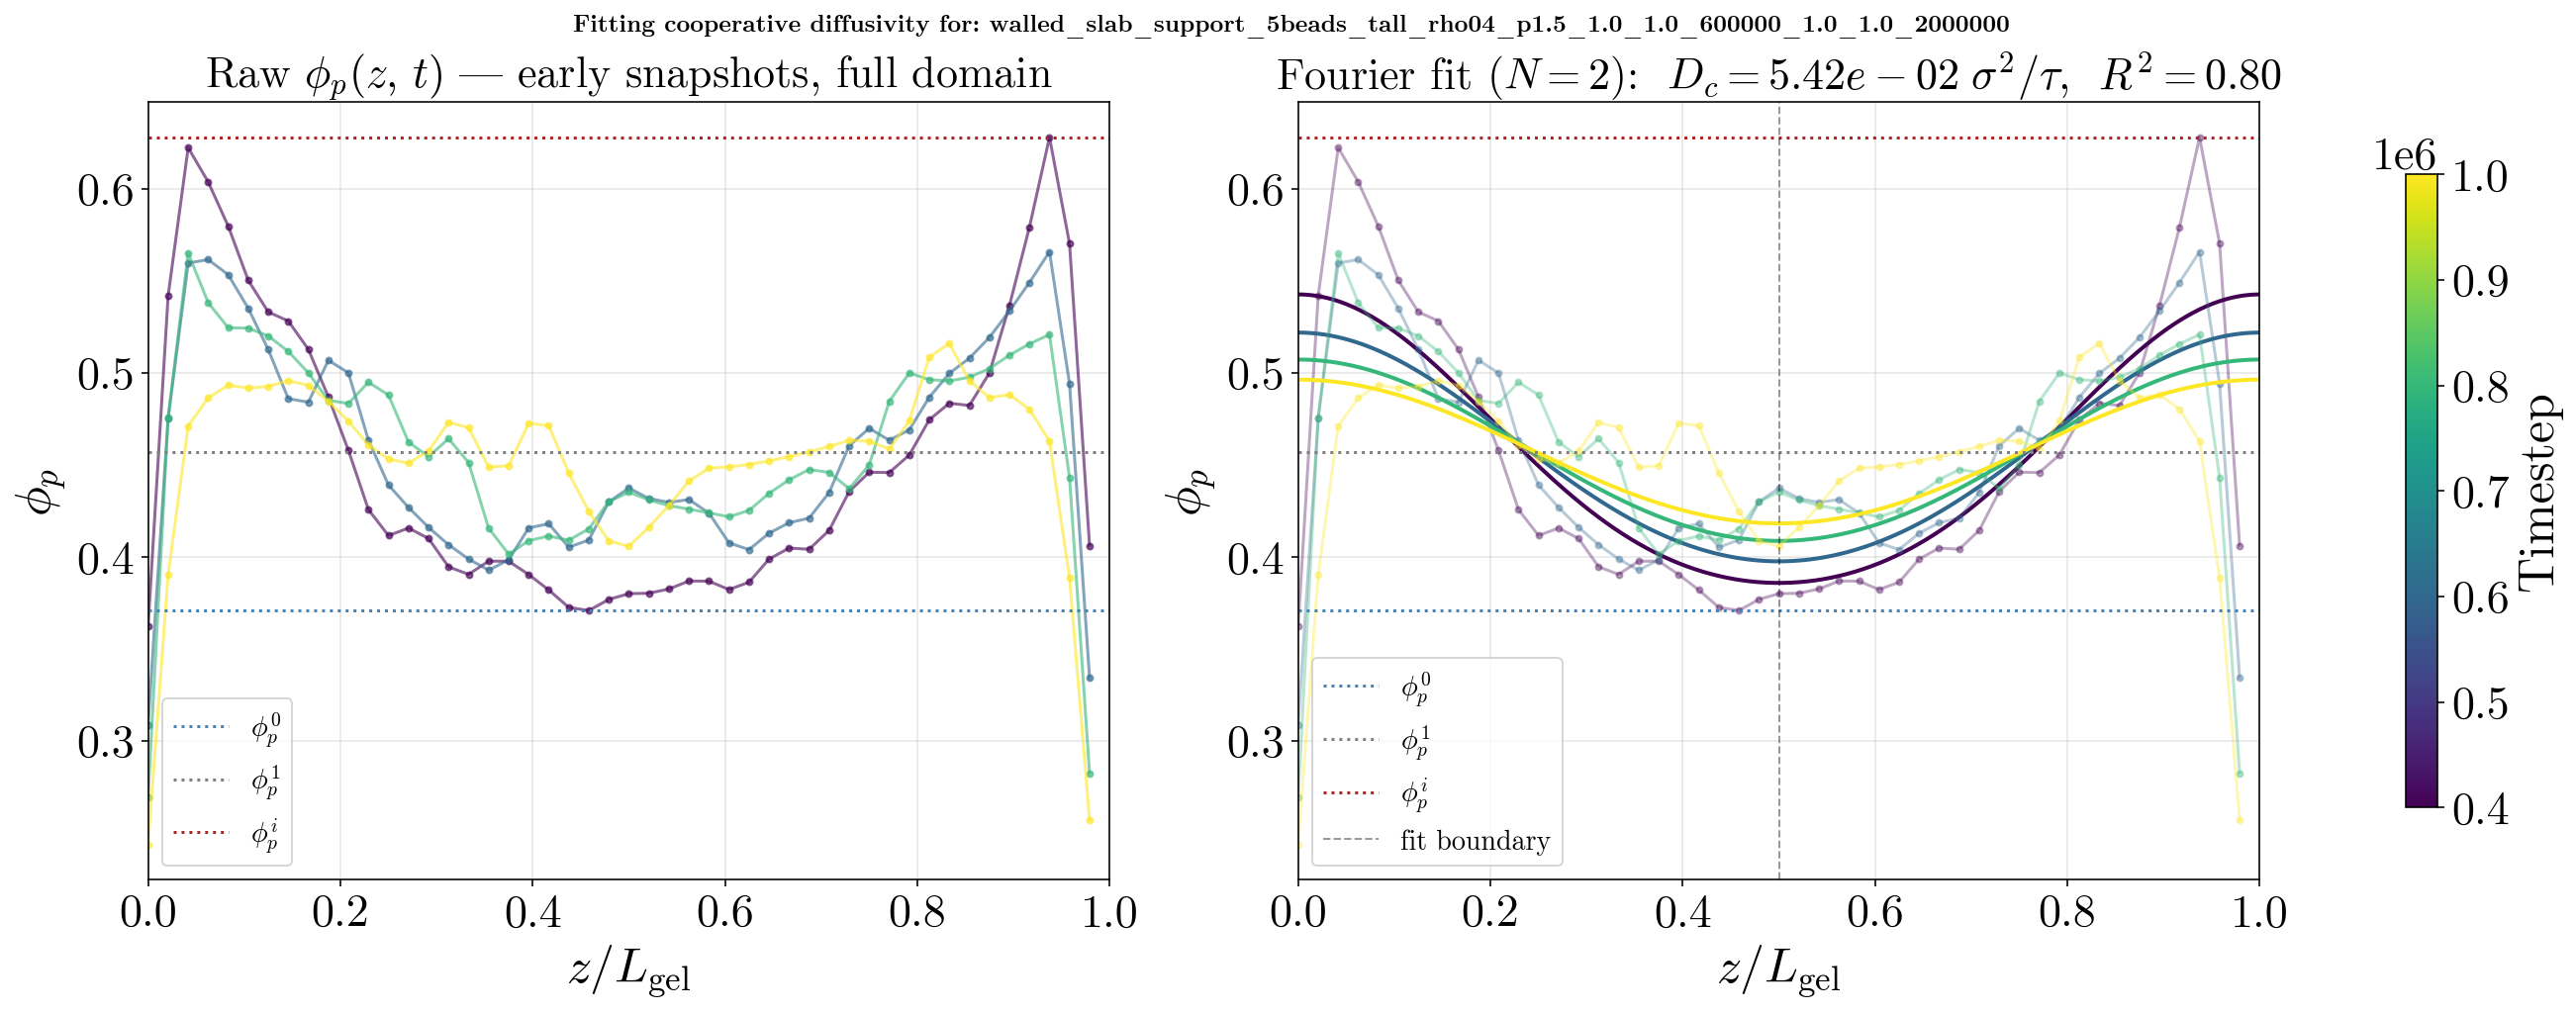

In [141]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
norm_t    = Normalize(vmin=times[early_idx[0]], vmax=times[early_idx[-1]])
cmap      = plt.cm.viridis
zhat_fine = np.linspace(0, 1, 600)

for i in early_idx:
    c = cmap(norm_t(times[i]))
    ax_l.plot(zhat, phi_gel[i], 'o-', color=c, ms=3, alpha=0.6)
    ax_r.plot(zhat, phi_gel[i], 'o-', color=c, ms=3, alpha=0.35)
    ax_r.plot(zhat_fine, fourier_model(zhat_fine, Dc_fit, dt_lj_arr[i]),
              '-', color=c, lw=2.0)

for ax in (ax_l, ax_r):
    ax.axhline(phi_p0, color='steelblue', ls=':', lw=1.5, label=r'$\phi_p^0$')
    ax.axhline(phi_p1, color='gray',      ls=':', lw=1.5, label=r'$\phi_p^1$')
    ax.axhline(phi_pi, color='firebrick', ls=':', lw=1.5,
               label=r'$\phi_p^i$')
    ax.set(xlabel=r'$z / L_\mathrm{gel}$', ylabel=r'$\phi_p$', xlim=(0, 1))
    ax.grid(alpha=0.3)

ax_l.legend(fontsize=14)
ax_l.set_title(r'Raw $\phi_p(z,\,t)$ — early snapshots, full domain')
ax_r.axvline(0.5, color='k', ls='--', lw=1, alpha=0.4, label='fit boundary')
ax_r.legend(fontsize=14)
ax_r.set_title(rf'Fourier fit ($N={N_modes}$):  $D_c = {Dc_fit:.2e}\ \sigma^2/\tau$,  $R^2 = {R2:.2f}$')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_t)
sm.set_array([])
fig.colorbar(sm, ax=[ax_l, ax_r], fraction=0.015, pad=0.04).set_label('Timestep')
fig.suptitle(
    f'Fitting cooperative diffusivity for: {sim_name}',
    fontsize=12, fontweight='bold')

out_fourier = Path(output_folder) / f'Dc_fourier_fit_{sim_name}.png'
plt.savefig(out_fourier, dpi=150, bbox_inches='tight')
print(f'Saved: {out_fourier}')
print(f'  R² (aggregate) = {R2:.6f}')
print(f'  R² per snapshot:')
for idx, r2 in zip(early_idx, R2_per):
    print(f'    step {times[idx]:.0f}  →  R² = {r2:.3f}')
plt.show()

## Step 5: Final-State Profiles

Voronoi volume fractions computed once for the final frame, used for all derived quantities and plots.

In [142]:
from scipy.interpolate import interp1d

idx_final = -1 # -1

# Stress components from LAMMPS
sig_p_final = all_sigma_p_zz[idx_final]
sig_s_final = all_sigma_s_zz[idx_final]

# --- Voronoi volume fractions (computed once) ---
print('Computing Voronoi volume fractions for final frame...')
_, box_final, atoms_final = read_lammpstrj_frame(traj_file, matched[idx_final][1])
box_bounds_final = {'x': box_final['x'], 'y': box_final['y'], 'z': box_final['z']}

z_vor, phi_p_vor, phi_s_vor = compute_volume_fractions_1d_voronoi(
    atoms_final, box_bounds_final, binWidth, 'z')

# Voronoi z grid normalised
zlo_f, zhi_f = box_final['z']
Lz_f = zhi_f - zlo_f
z_vor_norm = (z_vor - zlo_f) / Lz_f

# Interpolate Voronoi phi onto the stress bin grid
phi_p_final = interp1d(z_vor, phi_p_vor, bounds_error=False, fill_value=0.0)(z_coords)
phi_s_final = interp1d(z_vor, phi_s_vor, bounds_error=False, fill_value=0.0)(z_coords)


Computing Voronoi volume fractions for final frame...
  Checking for duplicate positions...
  Building Voronoi container (187096 atoms)...
  Container built (18.1s)
  Extracting cell volumes...
  Volumes extracted (2.1s)


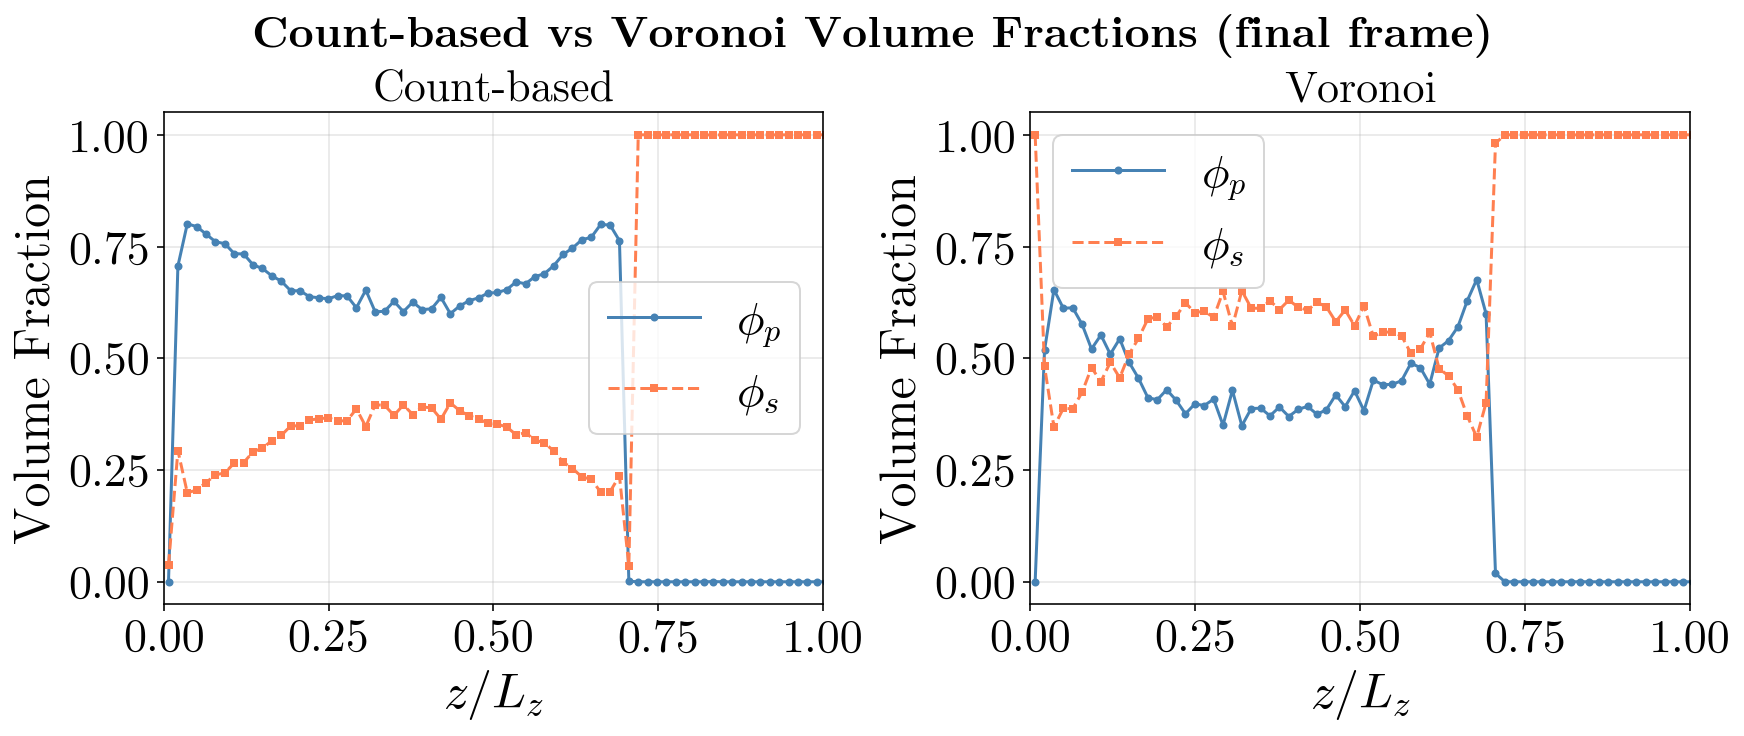

Saved: ../../flow_data_local/flow_plots/walled_slab_support_5beads_tall_rho04_p1.5_1.0_1.0_600000_1.0_1.0_2000000/final_state_profiles_walled_slab_support_5beads_tall_rho04_p1.5_1.0_1.0_600000_1.0_1.0_2000000.png


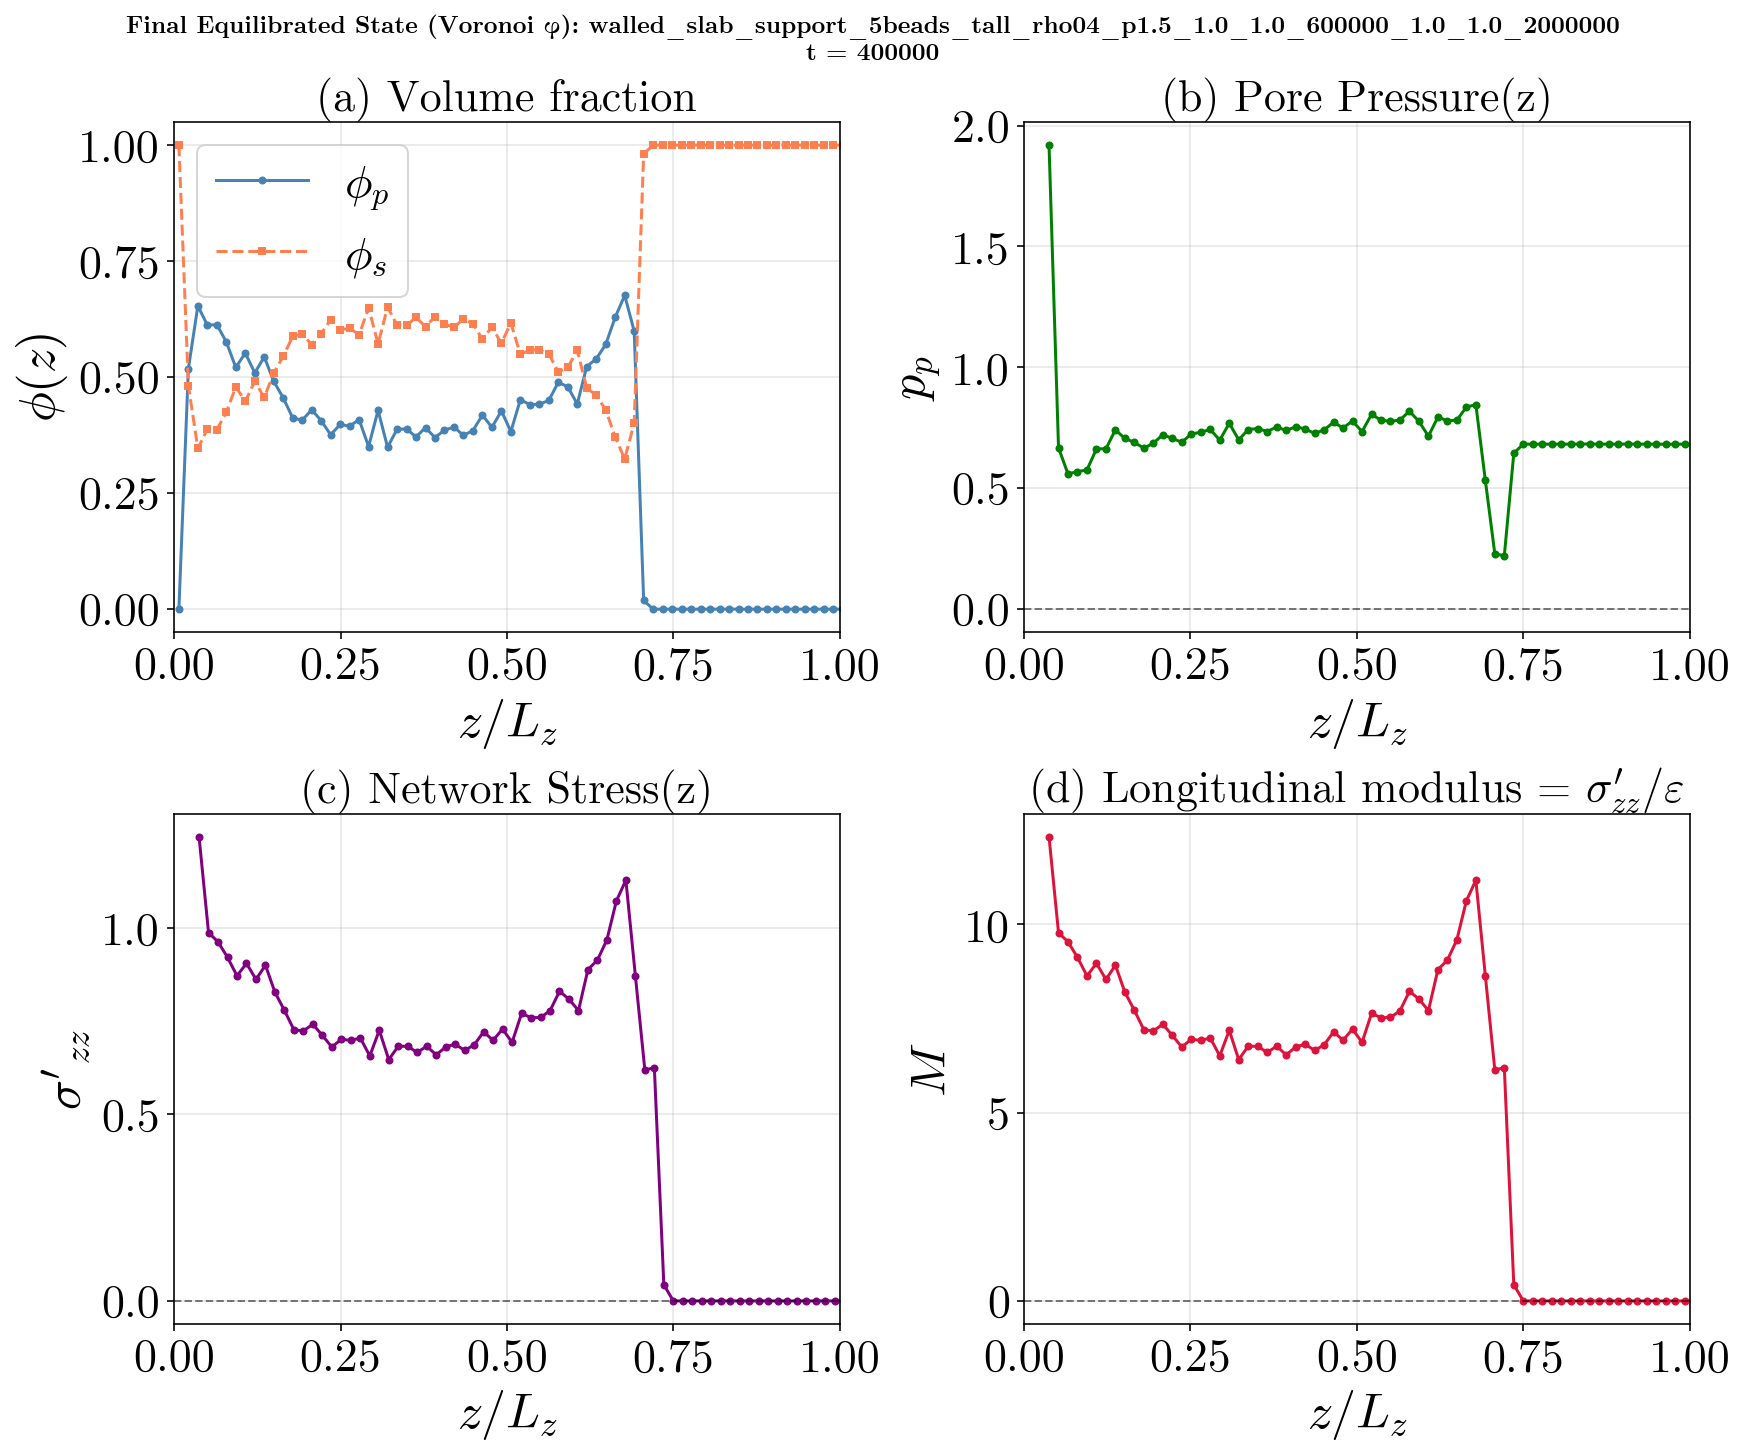

In [62]:
# --- Recompute derived quantities using Voronoi phi ---
phi_s_final_safe = np.where(phi_s_final > 1e-6, phi_s_final, np.nan)
p_p_final       = sig_s_final / phi_s_final_safe
sig_prime_final  = sig_p_final + phi_p_final * np.where(np.isnan(p_p_final), 0.0, p_p_final)

if abs(eps_final) < 1e-12:
    raise ValueError('Final strain ≈ 0 — cannot compute M')

M_final = sig_prime_final / eps_final

# --- Count-based phi (for comparison plot only) ---
z_cnt, phi_p_cnt, phi_s_cnt = compute_volume_fractions_1d(
    atoms_final, box_bounds_final, binWidth, 'z')

# --- Plot 1: Count-based vs Voronoi comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig.suptitle('Count-based vs Voronoi Volume Fractions (final frame)', fontweight='bold')

for ax, (phi_p, phi_s, z, label) in zip(axes, [
    (phi_p_cnt, phi_s_cnt, z_cnt, 'Count-based'),
    (phi_p_vor, phi_s_vor, z_vor, 'Voronoi')
]):
    ax.plot((z - zlo_f)/Lz_f, phi_p, 'o-', color='steelblue', ms=3, label=r'$\phi_p$')
    ax.plot((z - zlo_f)/Lz_f, phi_s, 's--', color='coral',    ms=3, label=r'$\phi_s$')
    ax.legend()
    ax.set(xlabel='$z/L_z$', ylabel='Volume Fraction', title=label, xlim=(0,1))
    ax.grid(alpha=0.3)

plt.savefig(Path(output_folder) / f'volfrac_comparison_{sim_name}.png', dpi=150)
plt.show()

fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
fig2.suptitle(
    f'Final Equilibrated State (Voronoi φ): {sim_name}\nt = {all_timesteps[idx_final]}',
    fontsize=12, fontweight='bold')

# (a) φ
ax = axes2[0, 0]
ax.plot(z_vor_norm, phi_p_vor, 'o-', label=r'$\phi_p$', color='steelblue', ms=3)
ax.plot(z_vor_norm, phi_s_vor, 's--', label=r'$\phi_s$', color='coral', ms=3)
ax.legend()
ax.set(xlabel='$z/L_z$', ylabel='$\phi(z)$', title='(a) Volume fraction', xlim=(0,1))
ax.grid(alpha=0.3)

# (b) p_p
ax = axes2[0, 1]
ax.plot(z_norm, p_p_final, 'o-', color='green', ms=3)
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax.set(xlabel='$z/L_z$', ylabel=r'$p_p$', title='(b) Pore Pressure(z)', xlim=(0,1))
ax.grid(alpha=0.3)

# (c) σ'
ax = axes2[1, 0]
ax.plot(z_norm, sig_prime_final, 'o-', color='purple', ms=3)
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax.set(xlabel='$z/L_z$', ylabel=r"$\sigma'_{zz}$", title=r"(c) Network Stress(z)", xlim=(0,1))
ax.grid(alpha=0.3)

# (d) M
ax = axes2[1, 1]
ax.plot(z_norm, M_final, 'o-', color='crimson', ms=3)
ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
ax.set(xlabel='$z/L_z$', ylabel='$M$',
       title=r'(d) Longitudinal modulus = $\sigma^{\prime}_{zz}/\varepsilon$', xlim=(0,1))
ax.grid(alpha=0.3)

out2 = Path(output_folder) / f'final_state_profiles_{sim_name}.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
print(f'Saved: {out2}')
plt.show()

## Step 6: Gel-Averaged M with Confidence Interval

**Procedure:**
1. Identify gel bins: where φ_p > threshold (0.05)
2. Extract M values from those bins: $\{M_1, M_2, \dots, M_n\}$
3. Compute sample mean: $\bar{M} = \frac{1}{n}\sum M_i$
4. Compute standard error: $\text{SEM} = s / \sqrt{n}$ where $s = \sqrt{\frac{1}{n-1}\sum(M_i - \bar{M})^2}$
5. Construct 95% CI using t-distribution with $n-1$ degrees of freedom:
   $$\text{CI} = \bar{M} \pm t_{0.975, n-1} \times \text{SEM}$$

**Interpretation:** The CI reflects **spatial heterogeneity** in the gel's stiffness.
Narrow band = uniform; wide band = some bins are stiffer/softer than average.

In [ ]:
print('='*70)
print('DERIVATION OF GEL-AVERAGED LONGITUDINAL MODULUS')
print('='*70)

# Step 1: Identify gel bins using Voronoi phi_p (interpolated onto stress grid)
gel_mask = phi_p_final > phi_gel_threshold
n_gel_bins = np.sum(gel_mask)
print(f'\n1. Gel bins identified: {n_gel_bins} / {len(phi_p_final)} (φ_p > {phi_gel_threshold})')

# Step 2: Extract M values
M_gel = M_final[gel_mask]
M_gel = M_gel[~np.isnan(M_gel)]  # remove any NaNs
n_valid = len(M_gel)
print(f'   Valid M values: {n_valid}')
print(f'   M_gel range: [{M_gel.min():.4f}, {M_gel.max():.4f}]')

if n_valid == 0:
    raise ValueError('No valid M values in gel region')

# Step 3: Sample mean
M_mean = np.mean(M_gel)
print(f'\n2. Sample mean: M̄ = {M_mean:.6f}')

# Step 4: Standard error
if n_valid == 1:
    print('\n   WARNING: only 1 data point — CI = point estimate')
    M_ci_lo, M_ci_hi = M_mean, M_mean
else:
    s = np.std(M_gel, ddof=1)  # sample std dev
    sem = stats.sem(M_gel)     # s / sqrt(n)
    print(f'\n3. Sample std dev: s = {s:.6f}')
    print(f'   Standard error: SEM = s/√n = {sem:.6f}')

    # Step 5: t-distribution CI
    df = n_valid - 1
    t_crit = stats.t.ppf((1+ci_level)/2, df)
    margin = t_crit * sem
    M_ci_lo = M_mean - margin
    M_ci_hi = M_mean + margin

    print(f'\n4. t-distribution (df={df}, α={1-ci_level}):')
    print(f'   Critical value: t_{{0.975, {df}}} = {t_crit:.4f}')
    print(f'   Margin of error: {margin:.6f}')

ci_pct = int(ci_level*100)
print(f'\n{"="*70}')
print(f'FINAL RESULT ({ci_pct}% Confidence Interval)')
print(f'{"="*70}')
print(f'  M = {M_mean:.4f}  [{M_ci_lo:.4f}, {M_ci_hi:.4f}]')
print(f'\nStrain: ε_zz = {eps_final:.4f}')
print(f'Gel thickness: L = {L_final:.2f}, ΔL = {dL_final:.2f}')
print('='*70)

## Optional: Save Data

In [ ]:
out_data = Path(output_folder) / f'longitudinal_modulus_final_{sim_name}.npz'
np.savez(out_data,
         z_coords=z_coords, z_norm=z_norm,
         z_centers=z_centers, z_centers_norm=z_centers_norm,
         z_vor=z_vor, z_vor_norm=z_vor_norm,
         final_timestep=all_timesteps[idx_final],
         L=L_final, dL=dL_final, eps=eps_final,
         phi_p=phi_p_final, phi_s=phi_s_final,
         phi_p_vor=phi_p_vor, phi_s_vor=phi_s_vor,
         p_p=p_p_final, sigma_p_zz=sig_p_final, sigma_s_zz=sig_s_final,
         sigma_prime_zz=sig_prime_final, M=M_final,
         M_mean=M_mean, M_ci_lo=M_ci_lo, M_ci_hi=M_ci_hi,
         ci_level=ci_level, n_gel_bins=n_gel_bins,
         sim_name=sim_name)
print(f'Saved: {out_data}')